# WALNUTS on Neal's funnel

This notebook mirrors the Neal's funnel experiment from the WALNUTS reference notebook {cite:p}`bourabee2025walnuts`, but uses the BlackJAX implementation. It compares standard NUTS with WALNUTS on the same target and reports marginal accuracy, orbit diagnostics, micro-step diagnostics, and approximate ESS per second.

The default run is intentionally small enough for documentation builds. Increase `NUM_WARMUP` and `NUM_SAMPLES` for a paper-style run.

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import blackjax

D_X = 10
D = D_X + 1
NUM_WARMUP = 10_000
NUM_SAMPLES = 90_000
BURN_IN = 10_000
SEED = 1

rng_key = jax.random.key(SEED)

## Target

Neal's funnel has `omega ~ Normal(0, 3)` and `x_i | omega ~ Normal(0, exp(omega / 2))`. The state is a vector whose first coordinate is `omega` and whose remaining coordinates are `x`.

In [2]:
def funnel_logdensity(theta):
    omega = theta[0]
    x = theta[1:]
    return -0.5 * omega**2 / 9.0 - 0.5 * jnp.sum(x**2) / jnp.exp(omega) - 0.5 * x.size * omega


def summarize(name, samples, elapsed, infos=None):
    kept = samples[BURN_IN:]
    omega = kept[:, 0]
    x = kept[:, 1:]
    ess_omega = float(blackjax.ess(omega[None, :]))
    r2 = jnp.sum(x**2, axis=1) / (D_X * jnp.exp(omega))
    out = {
        "sampler": name,
        "runtime_sec": elapsed,
        "omega_mean": float(jnp.mean(omega)),
        "omega_std": float(jnp.std(omega)),
        "omega_q025": float(jnp.quantile(omega, 0.025)),
        "omega_q500": float(jnp.quantile(omega, 0.500)),
        "omega_q975": float(jnp.quantile(omega, 0.975)),
        "scaled_radius_mean": float(jnp.mean(r2)),
        "ess_omega": ess_omega,
        "ess_per_sec": ess_omega / elapsed,
    }
    if infos is not None and hasattr(infos, "num_macro_steps"):
        out.update(
            mean_macro_steps=float(jnp.mean(infos.num_macro_steps)),
            mean_micro_steps=float(jnp.mean(infos.max_micro_steps)),
            no_refinement_rate=float(jnp.mean(infos.no_refinement_rate)),
            hit_max_micro_rate=float(jnp.mean(infos.hit_max_micro_doublings)),
        )
    return out


def run_chain(step_fn, initial_state, key, num_samples):
    keys = jax.random.split(key, num_samples)
    step = jax.jit(step_fn)

    def one_step(state, key):
        state, info = step(key, state)
        return state, (state.position, info)

    return jax.lax.scan(one_step, initial_state, keys)

## NUTS baseline

NUTS uses the standard BlackJAX window adaptation for step size and diagonal mass matrix.

In [3]:
rng_key, nuts_warmup_key, nuts_sample_key = jax.random.split(rng_key, 3)
initial_position = jnp.zeros(D)

nuts_warmup = blackjax.window_adaptation(
    blackjax.nuts,
    funnel_logdensity,
    is_mass_matrix_diagonal=True,
    max_num_doublings=8,
)
(nuts_state, nuts_parameters), _ = nuts_warmup.run(
    nuts_warmup_key, initial_position, NUM_WARMUP
)
nuts = blackjax.nuts(funnel_logdensity, **nuts_parameters)

t0 = time.time()
_, (nuts_samples, nuts_infos) = run_chain(nuts.step, nuts_state, nuts_sample_key, NUM_SAMPLES)
nuts_elapsed = time.time() - t0

## WALNUTS

WALNUTS keeps the local energy threshold fixed and adapts the macro step size toward a target no-refinement rate.

In [4]:
rng_key, walnuts_warmup_key, walnuts_sample_key = jax.random.split(rng_key, 3)

walnuts_warmup = blackjax.walnuts_adaptation(
    funnel_logdensity,
    inverse_mass_matrix=jnp.ones(D),
    initial_step_size=0.6,
    target_no_refinement_rate=0.8,
    energy_threshold=0.7,
    max_num_doublings=8,
    max_num_micro_doublings=8,
)
(walnuts_state, walnuts_parameters), _ = walnuts_warmup.run(
    walnuts_warmup_key, initial_position, NUM_WARMUP
)
walnuts_sampler = blackjax.walnuts(funnel_logdensity, **walnuts_parameters)

t0 = time.time()
_, (walnuts_samples, walnuts_infos) = run_chain(
    walnuts_sampler.step, walnuts_state, walnuts_sample_key, NUM_SAMPLES
)
walnuts_elapsed = time.time() - t0

## Diagnostics

In [5]:
summaries = [
    summarize("NUTS", nuts_samples, nuts_elapsed, nuts_infos),
    summarize("WALNUTS", walnuts_samples, walnuts_elapsed, walnuts_infos),
]

for row in summaries:
    print(row)

print("Target omega mean/std: 0 / 3")
print("Target omega 2.5%, 50%, 97.5%: -5.88, 0, 5.88")

{'sampler': 'NUTS', 'runtime_sec': 0.4779939651489258, 'omega_mean': 0.39398491382598877, 'omega_std': 2.699869394302368, 'omega_q025': -4.218220233917236, 'omega_q500': 0.2477618157863617, 'omega_q975': 6.012336254119873, 'scaled_radius_mean': 0.9875645041465759, 'ess_omega': 364.0128479003906, 'ess_per_sec': 761.5427692418193}
{'sampler': 'WALNUTS', 'runtime_sec': 1.3012208938598633, 'omega_mean': -0.27438294887542725, 'omega_std': 2.9995157718658447, 'omega_q025': -6.069402694702148, 'omega_q500': -0.29244792461395264, 'omega_q975': 5.605921745300293, 'scaled_radius_mean': 0.9948192834854126, 'ess_omega': 753.1494140625, 'ess_per_sec': 578.8021216201063, 'mean_macro_steps': 22.520044326782227, 'mean_micro_steps': 5.646711349487305, 'no_refinement_rate': 0.6406043171882629, 'hit_max_micro_rate': 0.0009111111285164952}
Target omega mean/std: 0 / 3
Target omega 2.5%, 50%, 97.5%: -5.88, 0, 5.88


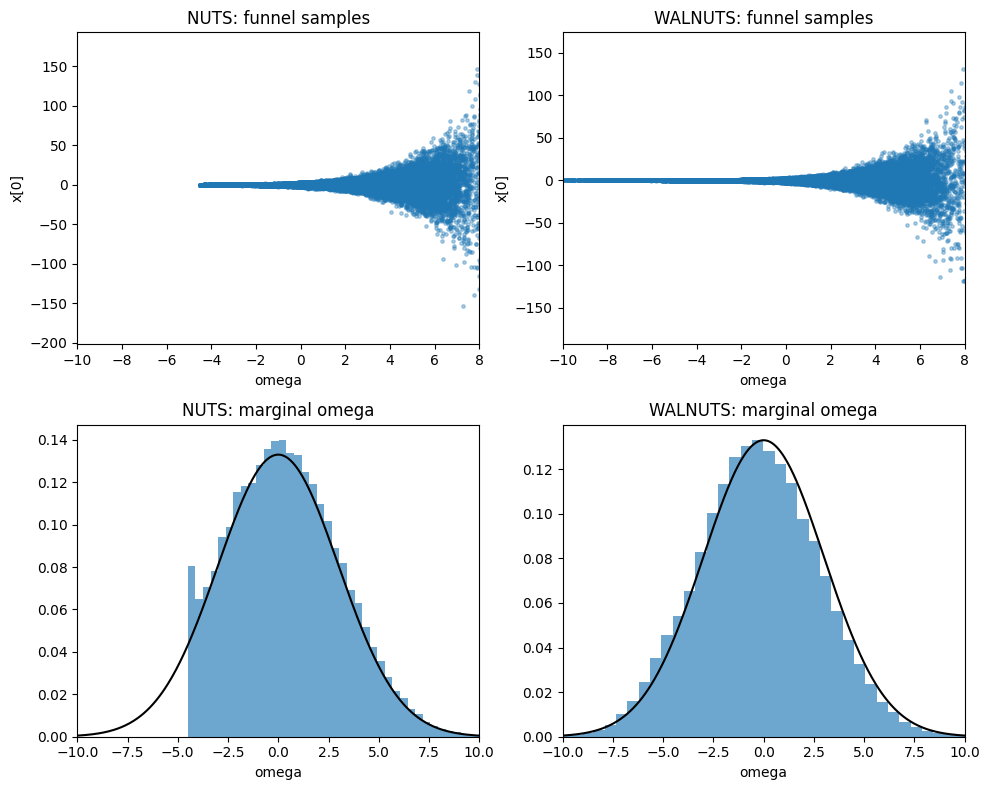

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, samples, title in [
    (axes[0, 0], nuts_samples, "NUTS"),
    (axes[0, 1], walnuts_samples, "WALNUTS"),
]:
    kept = np.asarray(samples[BURN_IN:])
    ax.scatter(kept[:, 0], kept[:, 1], s=6, alpha=0.35)
    ax.set_title(f"{title}: funnel samples")
    ax.set_xlabel("omega")
    ax.set_ylabel("x[0]")
    ax.set_xlim(-10, 8)

omega_grid = np.linspace(-10, 10, 400)
target_pdf = np.exp(-omega_grid**2 / 18.0) / np.sqrt(2 * np.pi * 9.0)
for ax, samples, title in [
    (axes[1, 0], nuts_samples, "NUTS"),
    (axes[1, 1], walnuts_samples, "WALNUTS"),
]:
    omega = np.asarray(samples[BURN_IN:, 0])
    ax.hist(omega, bins=40, density=True, alpha=0.65)
    ax.plot(omega_grid, target_pdf, color="black")
    ax.set_title(f"{title}: marginal omega")
    ax.set_xlabel("omega")
    ax.set_xlim(-10, 10)

plt.tight_layout()

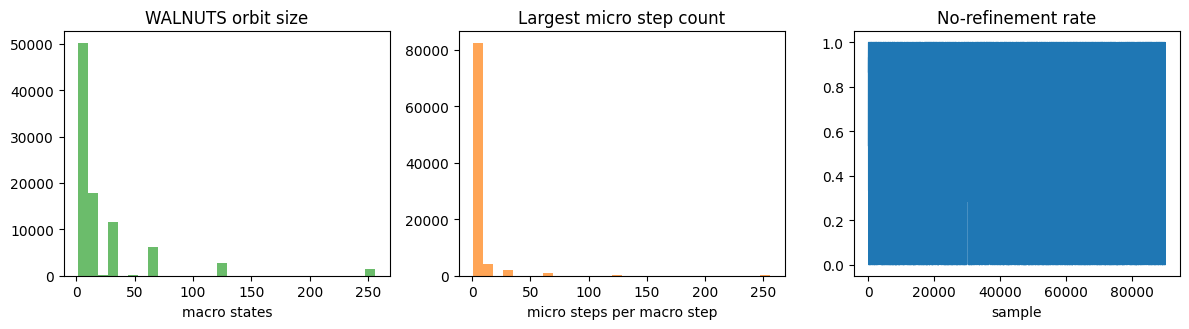

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

axes[0].hist(np.asarray(walnuts_infos.num_macro_steps), bins=30, color="C2", alpha=0.7)
axes[0].set_title("WALNUTS orbit size")
axes[0].set_xlabel("macro states")

axes[1].hist(np.asarray(walnuts_infos.max_micro_steps), bins=30, color="C1", alpha=0.7)
axes[1].set_title("Largest micro step count")
axes[1].set_xlabel("micro steps per macro step")

axes[2].plot(np.asarray(walnuts_infos.no_refinement_rate), lw=0.8)
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_title("No-refinement rate")
axes[2].set_xlabel("sample")

plt.tight_layout()